

<font size=6>**NFL Sentiment Analysis**</font>

In [1]:
# @title Importing Libraries
# Importing Libraries

import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
nlp = spacy.load('en_core_web_sm')
import nltk
nltk.download("vader_lexicon")
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import scipy

from textblob import TextBlob
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, r2_score

c:\Users\Pheon\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Pheon\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
reddit_data = pd.read_csv("NFL_reddit_data_2021.csv")
print(reddit_data.shape)
reddit_data.head()

(8353, 2)


,player,text
0,Caleb Farley,"body,score,controversiality"
1,Caleb Farley,"'[bro he just alon caus of covid 😭]',670,0,:Vi..."
2,Caleb Farley,"'[well , the good news be that he can't be wor..."
3,Caleb Farley,"'[injuri obvious a big factor , but if he heal..."
4,Caleb Farley,'[be my boy strap ? ? ? isaiah wilson bust rec...



<font size=6>**Data Preprocessing**</font>

In [3]:
#Removing null and duplicate rows
reddit_data.dropna(inplace=True)
reddit_data.drop_duplicates(inplace=True)
#Specifically extracting the post text from each row
reddit_data['body'] = reddit_data['text'].apply(lambda x: re.search(r"\[(.*?)\]", x).group(1) if re.search(r"\[(.*?)\]", x) != None else None)
#Cleaning up rows with no body, such as row 0
reddit_data.dropna(inplace=True)
reddit_data.head()

,player,text,body
1,Caleb Farley,"'[bro he just alon caus of covid 😭]',670,0,:Vi...",bro he just alon caus of covid 😭
2,Caleb Farley,"'[well , the good news be that he can't be wor...","well , the good news be that he can't be wors ..."
3,Caleb Farley,"'[injuri obvious a big factor , but if he heal...","injuri obvious a big factor , but if he health..."
4,Caleb Farley,'[be my boy strap ? ? ? isaiah wilson bust rec...,be my boy strap ? ? ? isaiah wilson bust recor...
5,Caleb Farley,"'[so sad he can ’ t celebr with anyon]',92,0,:...",so sad he can ’ t celebr with anyon


In [4]:
#Tokenizing
reddit_data['tokens'] = reddit_data['body'].apply(lambda x: [token.text for token in nlp(x)])
reddit_data.head()

,player,text,body,tokens
1,Caleb Farley,"'[bro he just alon caus of covid 😭]',670,0,:Vi...",bro he just alon caus of covid 😭,"[bro, he, just, alon, caus, of, covid, 😭]"
2,Caleb Farley,"'[well , the good news be that he can't be wor...","well , the good news be that he can't be wors ...","[well, ,, the, good, news, be, that, he, ca, n..."
3,Caleb Farley,"'[injuri obvious a big factor , but if he heal...","injuri obvious a big factor , but if he health...","[injuri, obvious, a, big, factor, ,, but, if, ..."
4,Caleb Farley,'[be my boy strap ? ? ? isaiah wilson bust rec...,be my boy strap ? ? ? isaiah wilson bust recor...,"[be, my, boy, strap, ?, ?, ?, isaiah, wilson, ..."
5,Caleb Farley,"'[so sad he can ’ t celebr with anyon]',92,0,:...",so sad he can ’ t celebr with anyon,"[so, sad, he, can, ’, t, celebr, with, anyon]"


In [5]:
#Removing Stopwords
def remove_stopword_tokens(tokens):
    document = nlp(" ".join(tokens))
    no_stopwords = [token.text for token in document if not token.is_stop]
    return no_stopwords

reddit_data["no_stop"] = reddit_data["tokens"].apply(remove_stopword_tokens)
reddit_data.head()

,player,text,body,tokens,no_stop
1,Caleb Farley,"'[bro he just alon caus of covid 😭]',670,0,:Vi...",bro he just alon caus of covid 😭,"[bro, he, just, alon, caus, of, covid, 😭]","[bro, alon, caus, covid, 😭]"
2,Caleb Farley,"'[well , the good news be that he can't be wor...","well , the good news be that he can't be wors ...","[well, ,, the, good, news, be, that, he, ca, n...","[,, good, news, wors, round, pick, .]"
3,Caleb Farley,"'[injuri obvious a big factor , but if he heal...","injuri obvious a big factor , but if he health...","[injuri, obvious, a, big, factor, ,, but, if, ...","[injuri, obvious, big, factor, ,, healthi, ,, ..."
4,Caleb Farley,'[be my boy strap ? ? ? isaiah wilson bust rec...,be my boy strap ? ? ? isaiah wilson bust recor...,"[be, my, boy, strap, ?, ?, ?, isaiah, wilson, ...","[boy, strap, ?, ?, ?, isaiah, wilson, bust, re..."
5,Caleb Farley,"'[so sad he can ’ t celebr with anyon]',92,0,:...",so sad he can ’ t celebr with anyon,"[so, sad, he, can, ’, t, celebr, with, anyon]","[sad, ’, t, celebr, anyon]"


In [6]:
#Lemmatization
def lemmatize_tokens(tokens):
    document = nlp(" ".join(tokens))
    lemm = [token.lemma_ for token in document]
    return lemm

reddit_data["lemmatized_tokens"] = reddit_data["no_stop"].apply(lemmatize_tokens)
reddit_data.head()

## Maybe add spell check

,player,text,body,tokens,no_stop,lemmatized_tokens
1,Caleb Farley,"'[bro he just alon caus of covid 😭]',670,0,:Vi...",bro he just alon caus of covid 😭,"[bro, he, just, alon, caus, of, covid, 😭]","[bro, alon, caus, covid, 😭]","[bro, alon, caus, covid, 😭]"
2,Caleb Farley,"'[well , the good news be that he can't be wor...","well , the good news be that he can't be wors ...","[well, ,, the, good, news, be, that, he, ca, n...","[,, good, news, wors, round, pick, .]","[,, good, news, wor, round, pick, .]"
3,Caleb Farley,"'[injuri obvious a big factor , but if he heal...","injuri obvious a big factor , but if he health...","[injuri, obvious, a, big, factor, ,, but, if, ...","[injuri, obvious, big, factor, ,, healthi, ,, ...","[injuri, obvious, big, factor, ,, healthi, ,, ..."
4,Caleb Farley,'[be my boy strap ? ? ? isaiah wilson bust rec...,be my boy strap ? ? ? isaiah wilson bust recor...,"[be, my, boy, strap, ?, ?, ?, isaiah, wilson, ...","[boy, strap, ?, ?, ?, isaiah, wilson, bust, re...","[boy, strap, ?, ?, ?, isaiah, wilson, bust, re..."
5,Caleb Farley,"'[so sad he can ’ t celebr with anyon]',92,0,:...",so sad he can ’ t celebr with anyon,"[so, sad, he, can, ’, t, celebr, with, anyon]","[sad, ’, t, celebr, anyon]","[sad, ', t, celebr, anyon]"


<font size=6>**Sentiment Analysis**</font>

In order to analyze the sentiment of the Reddit posts located in the NFL_reddit_data csv, I opted to use VADER. VADER was designed to be optimized for text based social media posts, and as Reddit is a social media and the majority of the observations found within the csv are text based, I figured that VADER would be useful in this context. VADER takes a string of a social media post and tokenizes it, and then calculates the sentiment, using a scalar score, of each individual word within a post. During this sentiment calculation, VADER also considers the capitilization and punctuation of these individual words in order to determine the score values. As such, this runs into a problem when we considered the preprocessing done in the previous step. stop words and lemmatization tends to remove some of the tools that VADER uses to determine sentiment, and as a result, the preprocessing actually makes VADER worse at analyzing the sentiment of the text. As a result, I opted to just use the original text of each reddit post in order to preserve as much as the original post's personality as possible.

In [7]:
model = SentimentIntensityAnalyzer()

def extract_score(text):
    #Calculates sentimentality
    score = model.polarity_scores(text)
    compound = score['compound']

    sentiment = 'neutral'
    #Increased cutoff at 0.5 in order to allow for more neutral sentiments
    if compound >= 0.5:
        sentiment = 'positive'
    if compound <= -0.5:
        sentiment = 'negative'
    return pd.Series([score['pos'], score['neg'], score['neu'], score["compound"], sentiment], index= ["pos", 'neg', 'neu', 'comp', 'sentiment'])

In [8]:
extracted_scores = reddit_data['body'].apply(extract_score)
reddit_data["sent_pos"] = extracted_scores['pos']
reddit_data["sent_neg"] = extracted_scores['neg']
reddit_data["sent_neu"] = extracted_scores['neu']
reddit_data["sent_comp"] = extracted_scores['comp']
reddit_data["sentiment"] = extracted_scores['sentiment']
reddit_data.head()

,player,text,body,tokens,no_stop,lemmatized_tokens,sent_pos,sent_neg,sent_neu,sent_comp,sentiment
1,Caleb Farley,"'[bro he just alon caus of covid 😭]',670,0,:Vi...",bro he just alon caus of covid 😭,"[bro, he, just, alon, caus, of, covid, 😭]","[bro, alon, caus, covid, 😭]","[bro, alon, caus, covid, 😭]",0.000,0.000,1.000,0.0000,neutral
2,Caleb Farley,"'[well , the good news be that he can't be wor...","well , the good news be that he can't be wors ...","[well, ,, the, good, news, be, that, he, ca, n...","[,, good, news, wors, round, pick, .]","[,, good, news, wor, round, pick, .]",0.263,0.000,0.737,0.6124,positive
3,Caleb Farley,"'[injuri obvious a big factor , but if he heal...","injuri obvious a big factor , but if he health...","[injuri, obvious, a, big, factor, ,, but, if, ...","[injuri, obvious, big, factor, ,, healthi, ,, ...","[injuri, obvious, big, factor, ,, healthi, ,, ...",0.254,0.000,0.746,0.7783,positive
4,Caleb Farley,'[be my boy strap ? ? ? isaiah wilson bust rec...,be my boy strap ? ? ? isaiah wilson bust recor...,"[be, my, boy, strap, ?, ?, ?, isaiah, wilson, ...","[boy, strap, ?, ?, ?, isaiah, wilson, bust, re...","[boy, strap, ?, ?, ?, isaiah, wilson, bust, re...",0.256,0.000,0.744,0.5330,positive
5,Caleb Farley,"'[so sad he can ’ t celebr with anyon]',92,0,:...",so sad he can ’ t celebr with anyon,"[so, sad, he, can, ’, t, celebr, with, anyon]","[sad, ’, t, celebr, anyon]","[sad, ', t, celebr, anyon]",0.000,0.361,0.639,-0.5256,negative



<font size=6>**Player Aggregation**</font>

In [9]:
aggregate_data = pd.DataFrame(columns=['Player', 'Percent_Positive', 'Total_Comments','Positive','Neutral','Negative', 'Average_Sentiment'])
for player_name in reddit_data['player'].unique():
    player_data = reddit_data.loc[reddit_data['player'] == player_name]
    counts = player_data['sentiment'].value_counts()
    per_pos = counts['positive'] / len(player_data)
    avg_sent = player_data['sent_comp'].mean()
    aggregate_data.loc[len(aggregate_data)] = [player_name, per_pos, len(player_data), counts['positive'], counts['neutral'], counts['negative'], avg_sent]

print(aggregate_data.shape)
aggregate_data.head()   


(64, 7)


,Player,Percent_Positive,Total_Comments,Positive,Neutral,Negative,Average_Sentiment
0,Caleb Farley,0.178404,213,38,146,29,0.065599
1,Azeez Ojulari,0.240000,100,24,63,13,0.105924
2,Greg Newsome II,0.223077,130,29,93,8,0.141843
3,Creed Humphrey,0.192308,156,30,111,15,0.123044
4,Dayo Odeyingbo,0.134328,67,9,54,4,0.097021



<font size=6>**Data Visualization**</font>

In [10]:
combined_player_data = pd.read_csv("combined_player_data.csv")
print(combined_player_data.shape)
combined_player_data.head()

(290, 22)


,Player,Score,Percent_Positive,Total_Comments,Positive,Neutral,Negative,Rk,AV,Round,...,College,From,To,Age,G,GS,AV.1,Pos,Team,-9999
0,Myles Garrett,82.214484,0.276596,188,52,98,38,6,68.0,1,...,Texas A&M,2017,2023,22-28,95,92,68.0,LDE,CLE,GarrMy00
1,Mitchell Trubisky,-1.202494,0.099291,141,14,78,49,55,39.0,1,...,North Carolina,2017,2023,23-29,66,55,39.0,QB,BUFCHIPIT,TrubMi00
2,Solomon Thomas,87.052286,0.213043,230,49,128,53,274,18.0,1,...,Stanford,2017,2023,22-28,93,30,18.0,RDE,LVRNYJSFO,ThomSo00
3,Leonard Fournette,130.602182,0.345133,226,78,106,42,41,42.0,1,...,Louisiana State,2017,2022,22-27,79,61,42.0,RB,JAXTAM,FourLe00
4,Corey Davis,51.446457,0.150685,219,33,128,58,75,34.0,1,...,Western Michigan,2017,2022,22-27,78,67,34.0,WR,NYJTEN,DaviCo03


In [11]:
#Merging the predicted and actual datasets to remove extraneous players from the actual dataset
merged_data = pd.merge(aggregate_data, combined_player_data, how='left', on=['Player'])
merged_data.dropna(inplace=True)
merged_data.head()

,Player,Percent_Positive_x,Total_Comments_x,Positive_x,Neutral_x,Negative_x,Average_Sentiment,Score,Percent_Positive_y,Total_Comments_y,...,College,From,To,Age,G,GS,AV.1,Pos,Team,-9999
0,Caleb Farley,0.178404,213,38,146,29,0.065599,64.087349,0.183962,212.0,...,Virginia Tech,2021.0,2022.0,23-24,12.0,2.0,1.0,CB,TEN,FarlCa00
1,Azeez Ojulari,0.240000,100,24,63,13,0.105924,47.549043,0.285714,98.0,...,Georgia,2021.0,2023.0,21-23,30.0,21.0,10.0,OLB,NYG,OjulAz00
2,Greg Newsome II,0.223077,130,29,93,8,0.141843,69.516023,0.296000,125.0,...,Northwestern,2021.0,2023.0,21-23,36.0,34.0,7.0,RCB,CLE,NewsGr00
3,Creed Humphrey,0.192308,156,30,111,15,0.123044,46.440366,0.237179,156.0,...,Oklahoma,2021.0,2023.0,22-24,45.0,45.0,22.0,C,KAN,HumpCr00
4,Dayo Odeyingbo,0.134328,67,9,54,4,0.097021,25.640497,0.109375,64.0,...,Vanderbilt,2021.0,2023.0,22-24,38.0,5.0,4.0,DE,IND,OdeyDa00


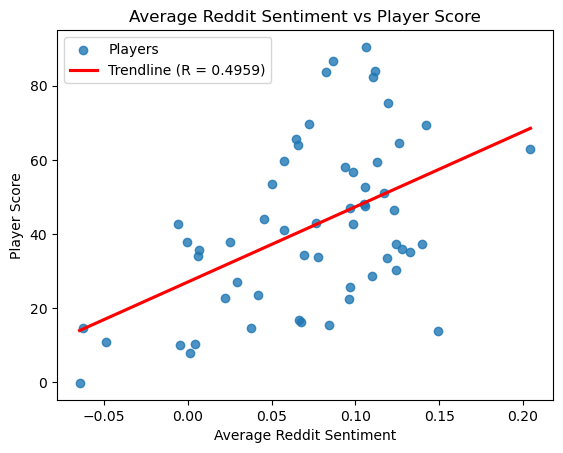

In [12]:
sns.regplot(x=merged_data['Average_Sentiment'], y=merged_data['Score'], ci=False, line_kws={'color':'red', 'label': f"Trendline (R = {scipy.stats.pearsonr(x=merged_data['Average_Sentiment'], y=merged_data['Score'])[0]:.4f})"}, label="Players")
plt.ylabel("Player Score")
plt.xlabel("Average Reddit Sentiment")
plt.title("Average Reddit Sentiment vs Player Score")
plt.legend()


When comparing the score of each player to the average sentiment towards them on reddit, there seems to be a weak but notable correlation between the two. This means that while not entirely accruate, a playe having a higher average sentiment should result in a higher player score or vice versa. 

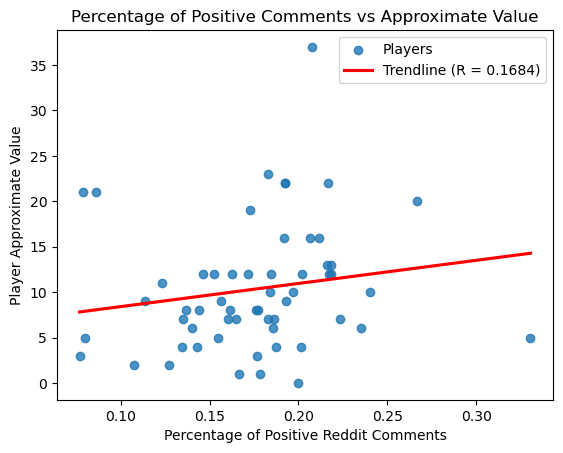

In [13]:
sns.regplot(x=merged_data['Percent_Positive_x'], y=merged_data['AV'], ci=False, line_kws={'color':'red', 'label': f"Trendline (R = {scipy.stats.pearsonr(x=merged_data['Percent_Positive_x'], y=merged_data['AV'])[0]:.4f})"}, label='Players')
plt.ylabel("Player Approximate Value")
plt.xlabel("Percentage of Positive Reddit Comments")
plt.title("Percentage of Positive Comments vs Approximate Value")
plt.legend()


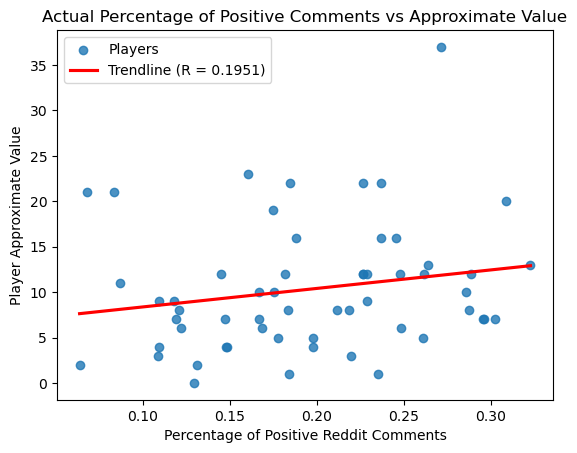

In [14]:
sns.regplot(x=merged_data['Percent_Positive_y'], y=merged_data['AV'], ci=False, line_kws={'color':'red', 'label': f"Trendline (R = {scipy.stats.pearsonr(x=merged_data['Percent_Positive_y'], y=merged_data['AV'])[0]:.4f})"}, label='Players')
plt.ylabel("Player Approximate Value")
plt.xlabel("Percentage of Positive Reddit Comments")
plt.title("Actual Percentage of Positive Comments vs Approximate Value")
plt.legend()


The correlation between the percentage of positive comments vs approximate value of the player seems to have a very low correlation, with an R score of around 0.08. This means that having a higher percentage of positive comments doesn't really indicate the player having increased approximate value. When compared the correlation between the actual statistics from the combined_player_data.csv, the correlation is a bit stronger, at 0.19, but still too low to be of significance. It does not seem that reddit sentiment analysis would allow us to gain any useful information about the approximate value of a player.


<font size=6>**Performance Evaluation**</font>

In [15]:
#Sorting data by positive percent and comparing its relevance based on median AV
sorted_merge = merged_data.sort_values(['Percent_Positive_x'], ascending=False)
med_av = merged_data["AV"].median()
sorted_merge["is_relevant"] = merged_data["AV"].apply(lambda x : x > med_av)
sorted_merge.head()

,Player,Percent_Positive_x,Total_Comments_x,Positive_x,Neutral_x,Negative_x,Average_Sentiment,Score,Percent_Positive_y,Total_Comments_y,...,From,To,Age,G,GS,AV.1,Pos,Team,-9999,is_relevant
30,Kadarius Toney,0.330435,115,38,68,9,0.204430,62.803614,0.261261,111.0,...,2021.0,2023.0,22-24,29.0,10.0,5.0,WR,KANNYG,ToneKa00,False
21,Penei Sewell,0.266667,150,40,88,22,0.105374,48.171872,0.308725,149.0,...,2021.0,2023.0,21-23,44.0,44.0,20.0,RT/LT,DET,SewePe00,True
1,Azeez Ojulari,0.240000,100,24,63,13,0.105924,47.549043,0.285714,98.0,...,2021.0,2023.0,21-23,30.0,21.0,10.0,OLB,NYG,OjulAz00,True
25,Eric Stokes,0.235294,85,20,50,15,0.066252,16.628337,0.168675,83.0,...,2021.0,2023.0,22-24,26.0,23.0,6.0,CB,GNB,StokEr00,False
2,Greg Newsome II,0.223077,130,29,93,8,0.141843,69.516023,0.296000,125.0,...,2021.0,2023.0,21-23,36.0,34.0,7.0,RCB,CLE,NewsGr00,False


In [16]:
precision_at_k_df = pd.DataFrame(columns=["K value", "Precision at K"])
k_range = range(5, 26, 5)
for k in k_range:
    counts = sorted_merge.head(k)['is_relevant'].value_counts()
    precision_at_k_df.loc[len(precision_at_k_df)] = [k, counts[True]/k]
precision_at_k_df.head()

,K value,Precision at K
0,5.0,0.400000
1,10.0,0.700000
2,15.0,0.733333
3,20.0,0.700000
4,25.0,0.640000


Using a similar method as the provided paper, I calculated the precision at K for K values 5, 10, 15, 20, and 25. In order to determine if a player was relevant, we compared the approximate value (AV) of the player to the median AVs of all players. If a player had an AV that was higher than the median, the player is considered as a relevant recommendation, and vice versa. When the K value is set to 5, the precision at K is relatively low at 0.4, but this value increases until the K value reaches around 15. This does mean that when looking at positive player sentiments from Reddit, you would be able to get a decently accurate reccomendations from the top 10-20 players with the highest positive sentiment.


<font size=6>**Real World Relevance**</font>

Based on the calculated Precisions at K, sentiment analysis on Reddit posts could prove useful in determining draft options for fantasy football, or the best players to bet on or scout for teams. Additionally, when deciding what players to field in a match, it could prove a useful tool. However, there are some clear weaknesses to this sentiment analysis. The correlation between positive sentiment and AV is quite low with a R value of only 0.17. This means that despite, being able to locate the individuals that are above the median value in regards to AV, it will not consistently locate the individuals with the highest AV. Additionally player performance can fluctuate in a way unrelated to the reddit sentimentality towards the player. When using sentiment analysis for drafting, betting, or scouting, I would advise caution as it is not guarenteed that you would have a good or even positive result. It can be used as a helpful tool, giving a rough idea of some high value individuals, but user intuition and analysis is highly advised in order to get the best results. However, when using it to field players within a game, it could prove a useful tool in determining which players should be playing and which should be on reserve. While caution is still necessary for fielding, the public sentiment of players could be useful in appeasing fans of the team when watching the matches, allowing the audience to feel more excited about the players currently playing the game and believing in their victory more.